# pHash Best Attack Evaluation
Runs the best evolved attack on all 100 image pairs and shows results.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

REPO = Path('..').resolve()
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'gigaevo-core'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import importlib.util, types

from evohash.dataset import load_image_pairs
from evohash.phf.phash import PHashWrapper

In [2]:
# ── Load 100 image pairs ──────────────────────────────────────────────────────
import evohash
data_dir = Path(evohash.__file__).parent.parent / 'data' / 'imagenet_val'

N_PAIRS = 100
phf = PHashWrapper()

pairs = load_image_pairs(data_dir, n_pairs=N_PAIRS)
sources  = [p[0] for p in pairs]
targets  = [p[1] for p in pairs]
target_hashes = [phf.compute(img) for img in targets]

print(f'Loaded {len(pairs)} pairs, threshold={phf.threshold}')

Loaded 100 pairs, threshold=12


In [3]:
# ── Load best attack ──────────────────────────────────────────────────────────
attack_path = REPO / 'problems' / 'phash' / 'best_attack.py'
spec = importlib.util.spec_from_file_location('best_attack', attack_path)
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

context = {
    'hash_fn':       phf,
    'threshold':     phf.threshold,
    'source_images': sources,
    'target_hashes': target_hashes,
    'target_images': targets,
}

print('Running attack on', N_PAIRS, 'pairs...')
result = mod.entrypoint(context)
attacked = result['attacked_images']
per_img  = result['metrics']
print('Done.')

Running attack on 100 pairs...
Done.


In [4]:
# ── Compute aggregate metrics ─────────────────────────────────────────────────
successes, l2s, queries, dists = [], [], [], []

for i, (src, atk, m) in enumerate(zip(sources, attacked, per_img)):
    atk_hash = phf.compute(atk)
    dist     = phf.distance(atk_hash, target_hashes[i])
    success  = dist <= phf.threshold

    src_arr = np.array(src).astype(float)
    atk_arr = np.array(atk).astype(float)
    l2 = np.linalg.norm((atk_arr - src_arr).flatten()) / np.sqrt(src_arr.size)

    successes.append(success)
    l2s.append(l2)
    queries.append(m.get('n_queries', 0))
    dists.append(dist)

asr        = np.mean(successes)
mean_l2    = np.mean(l2s)
mean_q     = np.mean(queries)
efficiency = asr / (mean_l2 + 1e-6)

print(f'ASR        : {asr:.3f}  ({int(sum(successes))}/{N_PAIRS})')
print(f'Mean L2    : {mean_l2:.3f}')
print(f'Mean queries: {mean_q:.1f}')
print(f'Efficiency : {efficiency:.5f}')

ASR        : 0.910  (91/100)
Mean L2    : 20.783
Mean queries: 20.2
Efficiency : 0.04379


In [5]:
# ── Per-image results table ───────────────────────────────────────────────────
import pandas as pd

df = pd.DataFrame({
    'pair':    range(N_PAIRS),
    'success': successes,
    'l2':      [round(x, 2) for x in l2s],
    'dist':    dists,
    'queries': queries,
})
print(df.to_string(index=False))

 pair  success    l2  dist  queries
    0     True 25.15  12.0       20
    1     True 28.34  12.0       21
    2     True 19.88  12.0       20
    3     True 31.76  12.0       20
    4     True 22.85  12.0       20
    5     True 13.95  12.0       20
    6     True 19.73  12.0       20
    7     True 14.13  12.0       20
    8     True 12.72  12.0       20
    9     True 22.45  12.0       20
   10     True  9.84  12.0       20
   11     True 11.25  12.0       20
   12     True 15.89  12.0       20
   13     True 35.25  12.0       21
   14     True 30.96  12.0       20
   15     True 20.03  12.0       20
   16     True 44.93  12.0       21
   17     True 12.42  12.0       20
   18     True 21.38  12.0       20
   19     True 23.95  12.0       20
   20     True 28.03  12.0       20
   21     True 16.80  12.0       20
   22     True 18.11  12.0       20
   23     True 15.25  12.0       20
   24     True 16.53  12.0       20
   25     True 26.08  12.0       20
   26     True 18.51  12.0  

In [ ]:
# ── Show all attacked images (source | attacked | target) ─────────────────────
COLS = 3
TRIPLET_W = 3.0
ROWS = N_PAIRS

fig, axes = plt.subplots(ROWS, COLS, figsize=(TRIPLET_W * COLS, TRIPLET_W * ROWS))
fig.suptitle('pHash Attack Results  (source | attacked | target)', fontsize=14, y=1.001)

col_labels = ['Source', 'Attacked', 'Target']
for col, lbl in enumerate(col_labels):
    axes[0, col].set_title(lbl, fontsize=10)

for i in range(ROWS):
    success = successes[i]
    color   = 'lime' if success else 'red'
    status  = '✓ OK' if success else '✗ FAIL'

    for col, img in enumerate([sources[i], attacked[i], targets[i]]):
        ax = axes[i, col]
        ax.imshow(img)
        ax.axis('off')

    # Метка на атакованном изображении
    ax = axes[i, 1]
    label = f'{status}  L2={l2s[i]:.1f}  dist={dists[i]}'
    ax.text(0.5, 0.02, label, transform=ax.transAxes,
            fontsize=7, color='white', ha='center', va='bottom',
            bbox=dict(facecolor=('darkgreen' if success else 'darkred'), alpha=0.7, pad=2))

    # Номер пары на source
    axes[i, 0].text(0.02, 0.98, f'#{i}', transform=axes[i, 0].transAxes,
                    fontsize=7, color='white', ha='left', va='top',
                    bbox=dict(facecolor='black', alpha=0.5, pad=2))

plt.tight_layout()
plt.savefig(REPO / 'notebooks' / 'eval_results.png', dpi=72, bbox_inches='tight')
plt.show()
print('Saved to notebooks/eval_results.png')

In [ ]:
# ── Top-10 best and worst examples ────────────────────────────────────────────
success_idx = [i for i in range(N_PAIRS) if successes[i]]
fail_idx    = [i for i in range(N_PAIRS) if not successes[i]]

top10   = sorted(success_idx, key=lambda i: l2s[i])[:10]
worst10 = sorted(fail_idx,    key=lambda i: dists[i])[:10]

if len(worst10) < 10:
    extra = sorted(success_idx, key=lambda i: l2s[i], reverse=True)
    for idx in extra:
        if idx not in worst10 and len(worst10) < 10:
            worst10.append(idx)

def show_examples(indices, title, title_color):
    n = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(title, fontsize=13, color=title_color, y=1.002)
    axes[0, 0].set_title('Source',   fontsize=10)
    axes[0, 1].set_title('Attacked', fontsize=10)
    axes[0, 2].set_title('Target',   fontsize=10)

    for row, i in enumerate(indices):
        success = successes[i]
        status  = '✓ OK' if success else '✗ FAIL'

        for col, img in enumerate([sources[i], attacked[i], targets[i]]):
            ax = axes[row, col]
            ax.imshow(img)
            ax.axis('off')

        # Метка на атакованном изображении
        ax = axes[row, 1]
        label = f'{status}  L2={l2s[i]:.1f}  dist={dists[i]}  q={int(queries[i])}'
        ax.text(0.5, 0.02, label, transform=ax.transAxes,
                fontsize=8, color='white', ha='center', va='bottom',
                bbox=dict(facecolor=('darkgreen' if success else 'darkred'), alpha=0.75, pad=2))

        # Номер пары
        axes[row, 0].text(0.02, 0.98, f'#{i}', transform=axes[row, 0].transAxes,
                          fontsize=8, color='white', ha='left', va='top',
                          bbox=dict(facecolor='black', alpha=0.5, pad=2))

    plt.tight_layout()
    plt.show()

show_examples(top10,   'Top-10 best attacks (lowest L2, successful)', 'darkgreen')
show_examples(worst10, 'Top-10 worst attacks (failed or highest L2)',  'darkred')

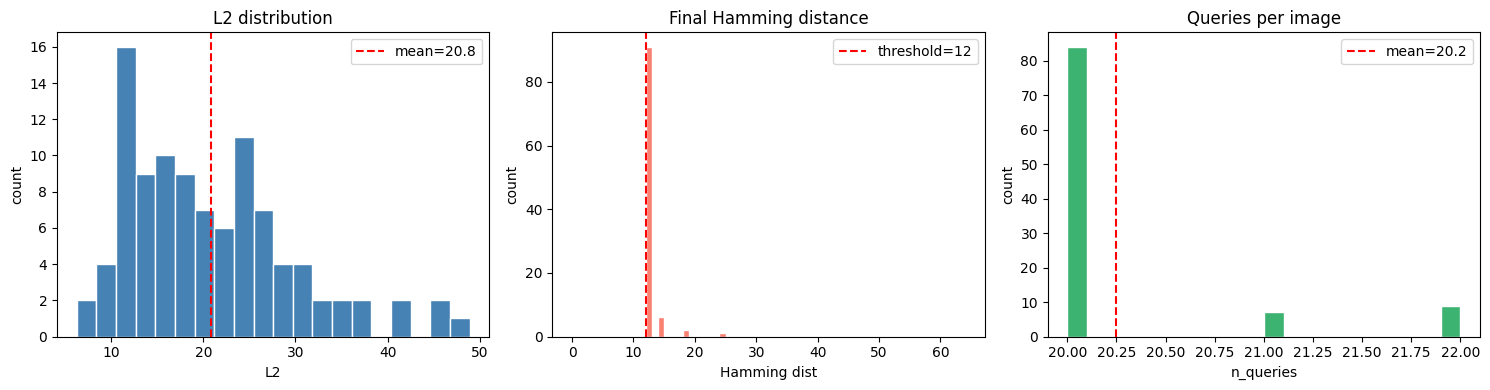

In [8]:
# ── Distribution plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(l2s, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('L2 distribution')
axes[0].set_xlabel('L2'); axes[0].set_ylabel('count')
axes[0].axvline(mean_l2, color='red', linestyle='--', label=f'mean={mean_l2:.1f}')
axes[0].legend()

axes[1].hist(dists, bins=range(0, 65), color='salmon', edgecolor='white')
axes[1].axvline(phf.threshold, color='red', linestyle='--', label=f'threshold={phf.threshold}')
axes[1].set_title('Final Hamming distance')
axes[1].set_xlabel('Hamming dist'); axes[1].set_ylabel('count')
axes[1].legend()

axes[2].hist(queries, bins=20, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Queries per image')
axes[2].set_xlabel('n_queries'); axes[2].set_ylabel('count')
axes[2].axvline(mean_q, color='red', linestyle='--', label=f'mean={mean_q:.1f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(REPO / 'notebooks' / 'eval_distributions.png', dpi=100, bbox_inches='tight')
plt.show()